In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load all processed station files into one dataframe
PROCESSED_DIR = Path("../data/processed")

frames = []
for filepath in PROCESSED_DIR.glob("*.parquet"):
    frames.append(pd.read_parquet(filepath))

df = pd.concat(frames, ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(f"Total rows: {len(df):,}")
print(f"Stations: {df['station_id'].nunique()}")
print(f"Sites: {df['site'].unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Total rows: 2,124,166
Stations: 115
Sites: ['caltech' 'jpl' 'office001']
Date range: 2018-04-30 18:00:00+00:00 to 2020-12-30 21:00:00+00:00


In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


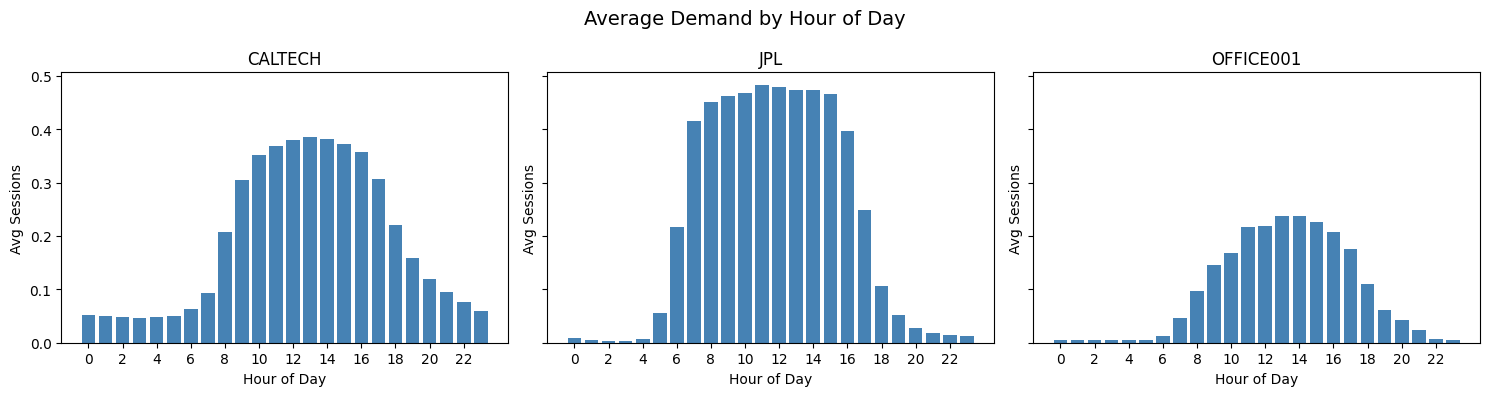

In [5]:
# Average sessions per hour of day, split by site
hourly_pattern = (
    df.groupby(["site", "hour"])["sessions"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, site in zip(axes, ["caltech", "jpl", "office001"]):
    site_data = hourly_pattern[hourly_pattern["site"] == site]
    ax.bar(site_data["hour"], site_data["sessions"], color="steelblue")
    ax.set_title(site.upper())
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Sessions")
    ax.set_xticks(range(0, 24, 2))

plt.suptitle("Average Demand by Hour of Day", fontsize=14)
plt.tight_layout()
plt.show()

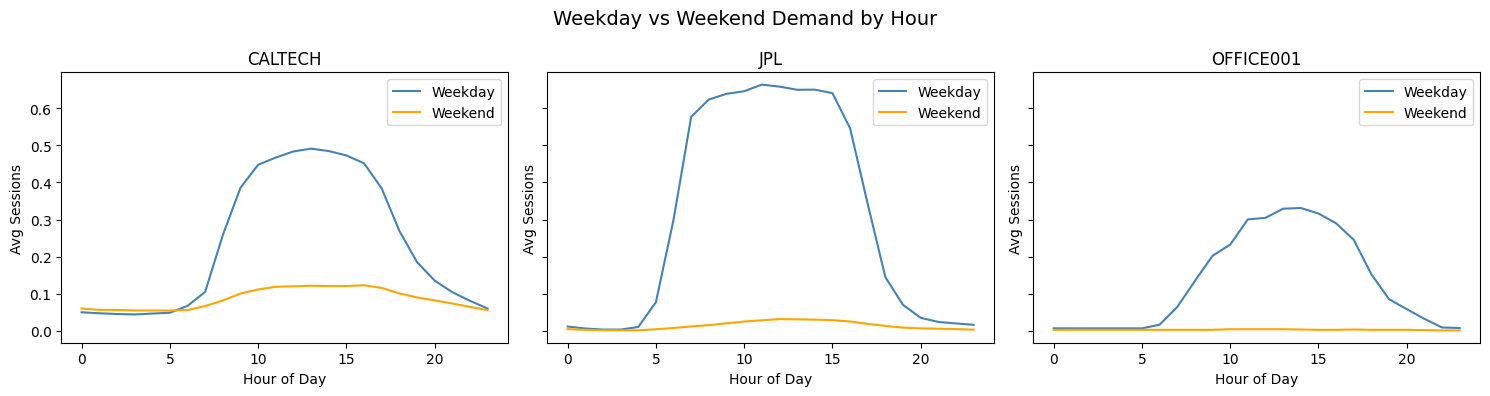

In [6]:
# Average demand by hour, split by weekday vs weekend, per site
df["day_type"] = df["is_weekend"].map({0: "Weekday", 1: "Weekend"})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, site in zip(axes, ["caltech", "jpl", "office001"]):
    site_data = df[df["site"] == site]
    pattern = site_data.groupby(["day_type", "hour"])["sessions"].mean().reset_index()
    
    for day_type, color in [("Weekday", "steelblue"), ("Weekend", "orange")]:
        subset = pattern[pattern["day_type"] == day_type]
        ax.plot(subset["hour"], subset["sessions"], label=day_type, color=color)
    
    ax.set_title(site.upper())
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Sessions")
    ax.legend()

plt.suptitle("Weekday vs Weekend Demand by Hour", fontsize=14)
plt.tight_layout()
plt.show()

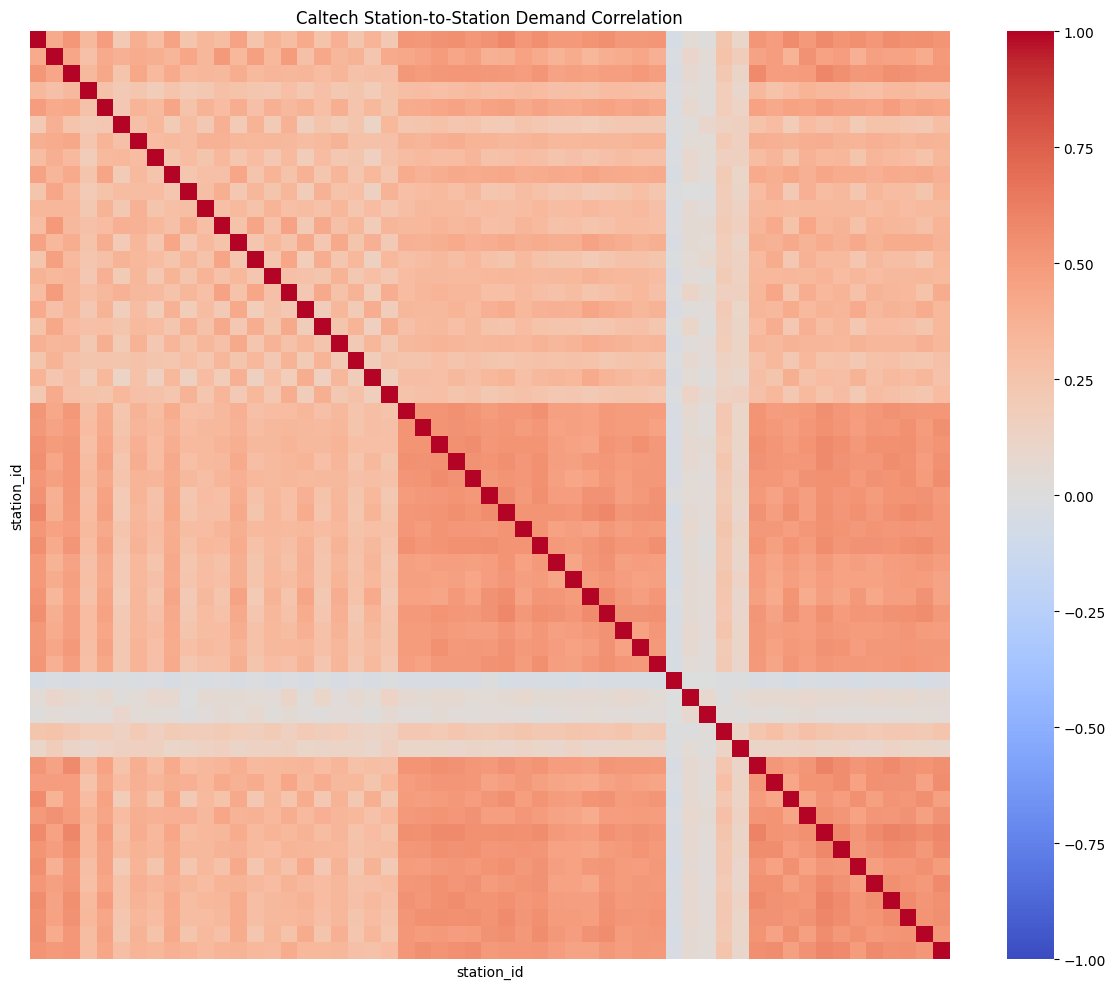

Mean correlation: 0.333
Min correlation:  -0.053
Max correlation:  0.609


In [7]:
# Do stations at the same site show correlated demand patterns?
# This is the empirical justification for transfer learning

# Take hourly demand for all caltech stations, pivot to wide format
caltech_stations = df[df["site"] == "caltech"].copy()

pivot = caltech_stations.pivot_table(
    index="timestamp",
    columns="station_id",
    values="sessions",
    aggfunc="sum"
).fillna(0)

# Compute correlation between all station pairs
corr = pivot.corr()

# Plot heatmap — if stations are correlated, transfer learning is justified
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    xticklabels=False,
    yticklabels=False
)
plt.title("Caltech Station-to-Station Demand Correlation")
plt.tight_layout()
plt.show()

print(f"Mean correlation: {corr.values[corr.values < 1].mean():.3f}")
print(f"Min correlation:  {corr.values[corr.values < 1].min():.3f}")
print(f"Max correlation:  {corr.values[corr.values < 1].max():.3f}")

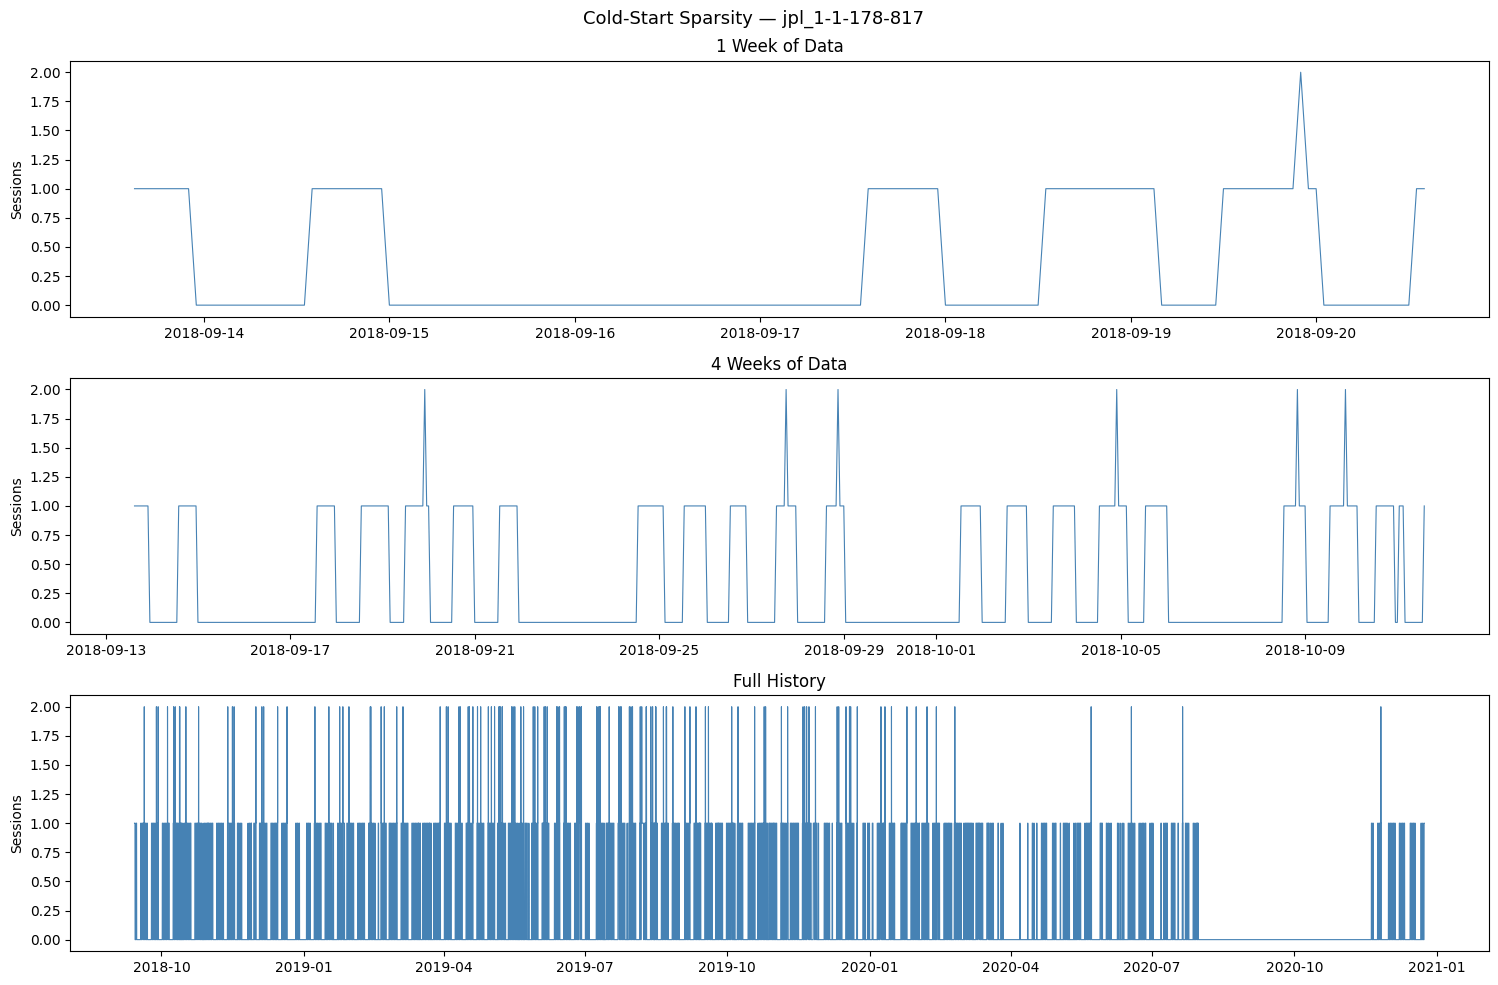

1 week  : 168 hours, 59 total sessions
4 weeks : 672 hours, 241 total sessions
Full    : 19972 hours, 5713 total sessions


In [8]:
sample_station = df[df["site"] == "jpl"]["station_id"].unique()[0]
station_df = df[df["station_id"] == sample_station].sort_values("timestamp")

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharey=True)

windows = [
    ("1 Week of Data", 168),
    ("4 Weeks of Data", 672),
    ("Full History", len(station_df)),
]

for ax, (title, hours) in zip(axes, windows):
    subset = station_df.head(hours)
    ax.plot(subset["timestamp"], subset["sessions"], color="steelblue", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Sessions")
    ax.set_xlabel("")

plt.suptitle(f"Cold-Start Sparsity — {sample_station}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"1 week  : {168} hours, {station_df.head(168)['sessions'].sum()} total sessions")
print(f"4 weeks : {672} hours, {station_df.head(672)['sessions'].sum()} total sessions")
print(f"Full    : {len(station_df)} hours, {station_df['sessions'].sum()} total sessions")

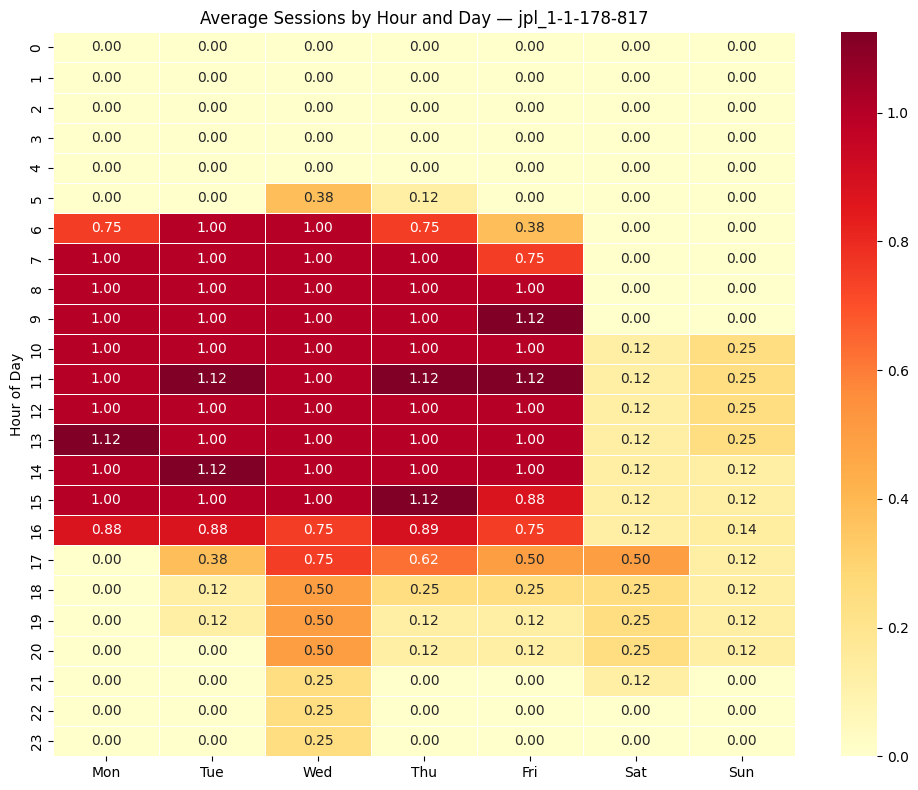

In [9]:
# Which hours of which days have zero demand?
# This shows the weekly pattern visually as a heatmap

sample_station = df[df["site"] == "jpl"]["station_id"].unique()[0]
station_df = df[df["station_id"] == sample_station].copy()

# Take 8 weeks for clarity
station_df = station_df.sort_values("timestamp").head(168 * 8)
station_df["week"] = (station_df["timestamp"].dt.isocalendar().week
                      - station_df["timestamp"].dt.isocalendar().week.min())
station_df["day"] = station_df["timestamp"].dt.dayofweek

pivot = station_df.pivot_table(
    index="hour",
    columns="day",
    values="sessions",
    aggfunc="mean"
).fillna(0)

pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)
plt.title(f"Average Sessions by Hour and Day — {sample_station}")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

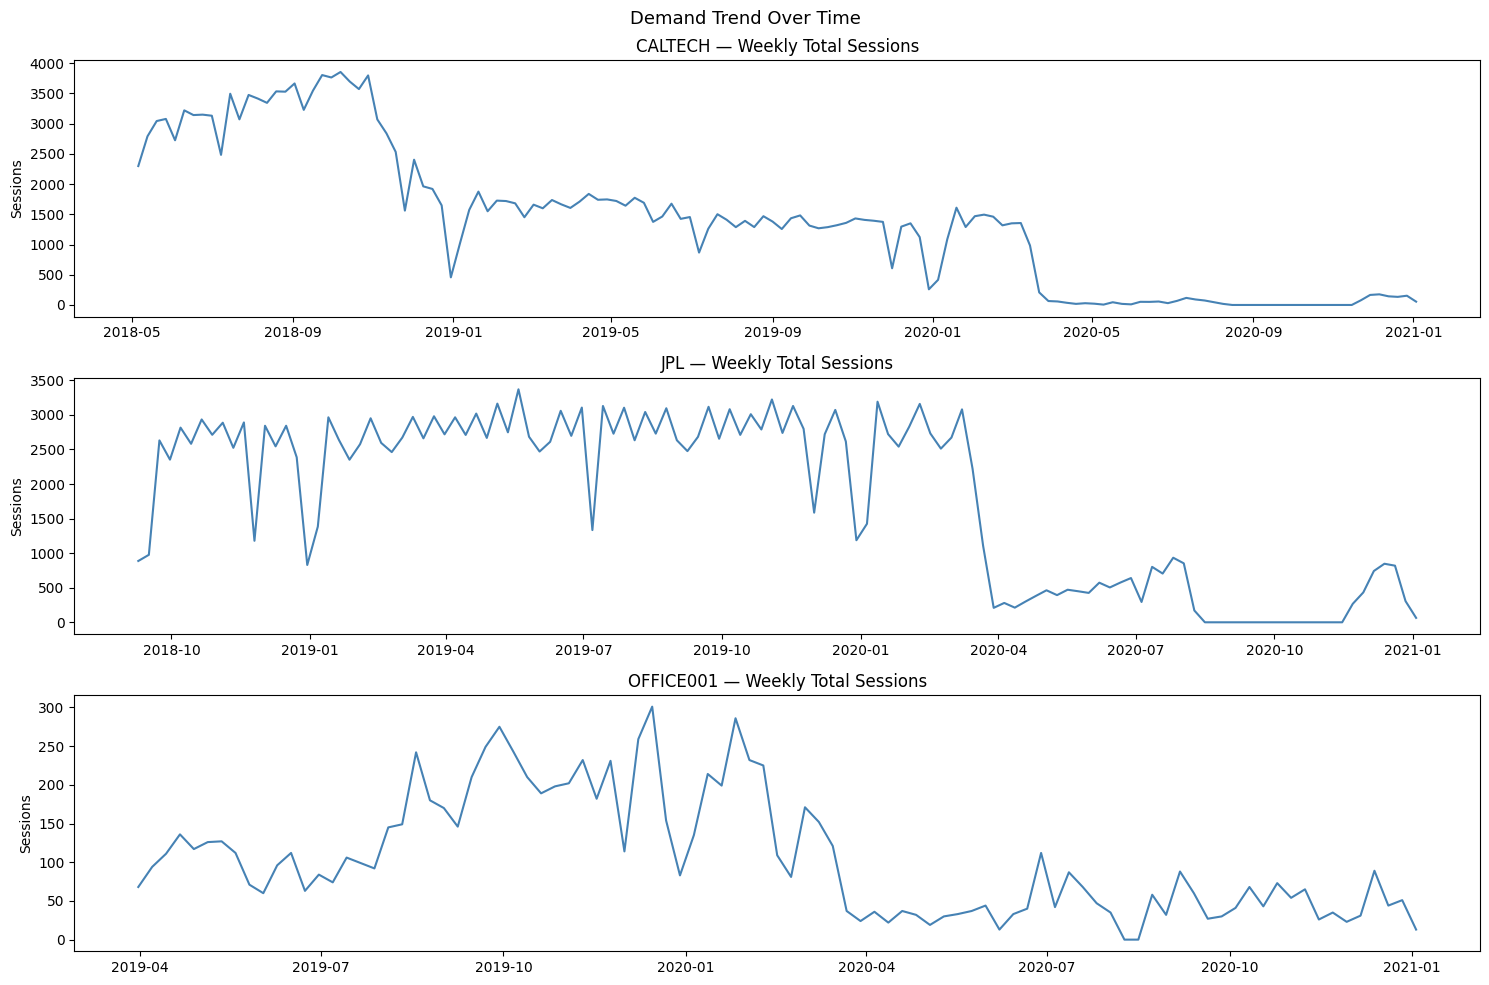

In [10]:
# Is demand growing over time? Declining? Stable?
# This matters because a model trained on 2018 data
# should still be valid for 2020 predictions

weekly_demand = (
    df.groupby(["site", pd.Grouper(key="timestamp", freq="W")])["sessions"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharey=False)

for ax, site in zip(axes, ["caltech", "jpl", "office001"]):
    site_data = weekly_demand[weekly_demand["site"] == site]
    ax.plot(site_data["timestamp"], site_data["sessions"], color="steelblue")
    ax.set_title(f"{site.upper()} — Weekly Total Sessions")
    ax.set_ylabel("Sessions")

plt.suptitle("Demand Trend Over Time", fontsize=13)
plt.tight_layout()
plt.show()

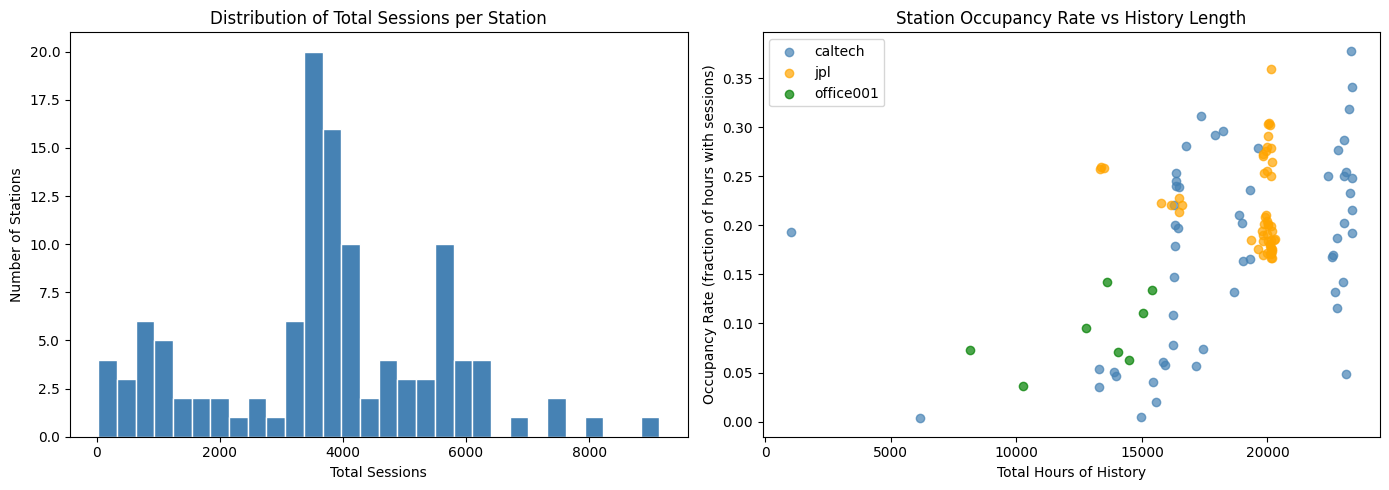

           count      mean       std       min       25%       50%       75%  \
site                                                                           
caltech     55.0  0.177957  0.095787  0.003401  0.093460  0.193035  0.249127   
jpl         52.0  0.219174  0.046770  0.166724  0.182931  0.201360  0.258098   
office001    8.0  0.090826  0.036674  0.036282  0.069223  0.084468  0.116555   

                max  
site                 
caltech    0.377840  
jpl        0.358934  
office001  0.142542  


In [11]:
# How much data does each station actually have?
# This shows which stations are data-rich vs data-poor

station_stats = (
    df.groupby(["station_id", "site"])
    .agg(
        total_hours=("sessions", "count"),
        total_sessions=("sessions", "sum"),
        nonzero_hours=("sessions", lambda x: (x > 0).sum())
    )
    .reset_index()
)

station_stats["occupancy_rate"] = (
    station_stats["nonzero_hours"] / station_stats["total_hours"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of total sessions per station
axes[0].hist(
    station_stats["total_sessions"],
    bins=30,
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Distribution of Total Sessions per Station")
axes[0].set_xlabel("Total Sessions")
axes[0].set_ylabel("Number of Stations")

# Occupancy rate per station colored by site
colors = {"caltech": "steelblue", "jpl": "orange", "office001": "green"}
for site in ["caltech", "jpl", "office001"]:
    subset = station_stats[station_stats["site"] == site]
    axes[1].scatter(
        subset["total_hours"],
        subset["occupancy_rate"],
        label=site,
        color=colors[site],
        alpha=0.7
    )

axes[1].set_title("Station Occupancy Rate vs History Length")
axes[1].set_xlabel("Total Hours of History")
axes[1].set_ylabel("Occupancy Rate (fraction of hours with sessions)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(station_stats.groupby("site")["occupancy_rate"].describe())

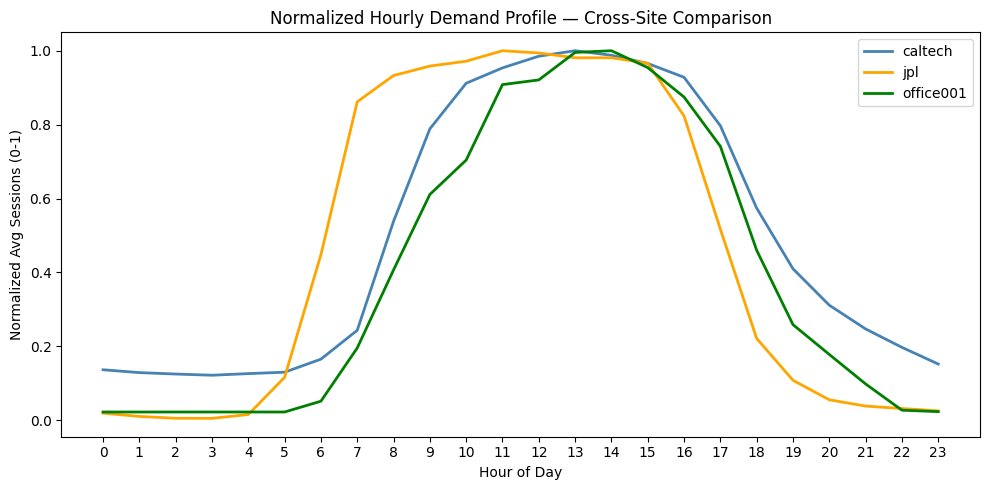

caltech vs jpl: correlation = 0.861
caltech vs office001: correlation = 0.992
jpl vs office001: correlation = 0.861


In [12]:
# Compare average hourly demand profiles across sites
# If shapes are similar, transfer learning is justified across sites

site_hourly = (
    df.groupby(["site", "hour"])["sessions"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
for site, color in [("caltech", "steelblue"), 
                     ("jpl", "orange"), 
                     ("office001", "green")]:
    subset = site_hourly[site_hourly["site"] == site]
    # Normalize to 0-1 so shapes are comparable regardless of scale
    normalized = subset["sessions"] / subset["sessions"].max()
    plt.plot(subset["hour"], normalized, label=site, color=color, linewidth=2)

plt.title("Normalized Hourly Demand Profile — Cross-Site Comparison")
plt.xlabel("Hour of Day")
plt.ylabel("Normalized Avg Sessions (0-1)")
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# Compute correlation between site profiles
profiles = {}
for site in ["caltech", "jpl", "office001"]:
    subset = site_hourly[site_hourly["site"] == site]["sessions"].values
    profiles[site] = subset / subset.max()

import numpy as np
for s1 in ["caltech", "jpl", "office001"]:
    for s2 in ["caltech", "jpl", "office001"]:
        if s1 < s2:
            corr = np.corrcoef(profiles[s1], profiles[s2])[0, 1]
            print(f"{s1} vs {s2}: correlation = {corr:.3f}")

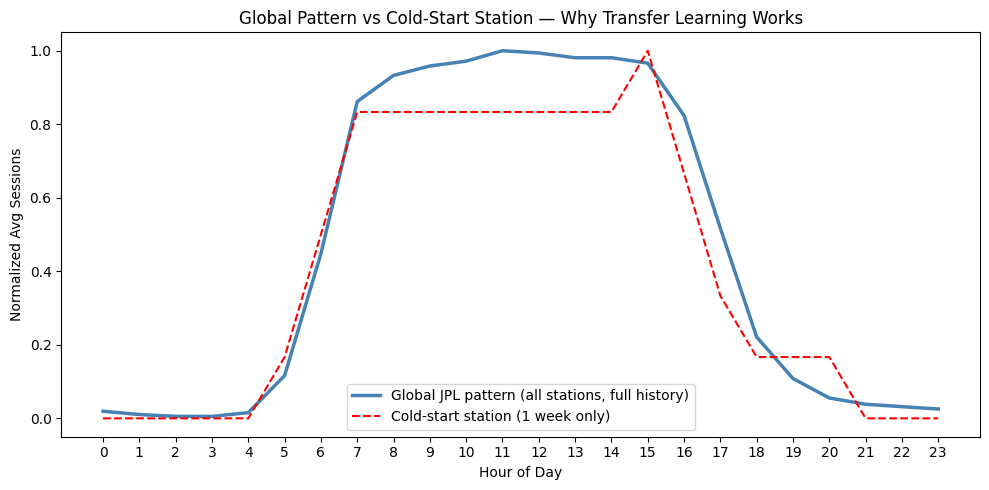

In [13]:
# This is the core visualization of why transfer learning works
# A new station with 1 week of data is noisy
# The global pattern is clean and immediately usable

# Pick one JPL station as the "new" cold-start station
cold_start_station = df[df["site"] == "jpl"]["station_id"].unique()[0]
station_df = df[df["station_id"] == cold_start_station].sort_values("timestamp")

# 1 week of data for this station
one_week = station_df.head(168)
one_week_profile = one_week.groupby("hour")["sessions"].mean()

# Global JPL pattern (all stations, full history)
global_profile = (
    df[df["site"] == "jpl"]
    .groupby("hour")["sessions"]
    .mean()
)

# Normalize both
one_week_norm = one_week_profile / one_week_profile.max() if one_week_profile.max() > 0 else one_week_profile
global_norm = global_profile / global_profile.max()

plt.figure(figsize=(10, 5))
plt.plot(global_norm.index, global_norm.values, 
         color="steelblue", linewidth=2.5, label="Global JPL pattern (all stations, full history)")
plt.plot(one_week_norm.index, one_week_norm.values, 
         color="red", linewidth=1.5, linestyle="--", label="Cold-start station (1 week only)")

plt.title("Global Pattern vs Cold-Start Station — Why Transfer Learning Works")
plt.xlabel("Hour of Day")
plt.ylabel("Normalized Avg Sessions")
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()